In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import duckdb
import functools
import re
import pickle
from pathlib import Path
import glob
conn = duckdb.connect()
@functools.lru_cache(maxsize=1024)
def q(query: str):
    return conn.execute(query).df()

In [34]:
with open('results/zonestats_r10_maxza/_r10cfg.pkl', 'rb') as f:
    cfgs = pickle.load(f)

pd.DataFrame(cfgs)

,1,2,3,4,5,6,7,8,9,10,...,243,244,245,246,247,248,249,250,251,252
in,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,traces/sim/cf_a.bin.zst,...,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst,traces/sim/cf_g.bin.zst
cache_gib,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048,...,2048,2048,2048,2048,2048,2048,2048,2048,2048,2048
ksr,2,2,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
cache_type,lru,lru,lru,lru,lru,lru,lru,lru,lru,lru,...,lru,lru,lru,lru,lru,lru,lru,lru,lru,lru
mode,ml,ml,ml,ml,ml,ml,ml,ml,ml,ml,...,ml,ml,ml,ml,ml,ml,ml,ml,ml,ml
model,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,...,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx,models/v10_cf_rfc.onnx
mlthres,1,1,1,1,1,1,1,0.95,0.95,0.95,...,0.68,0.68,0.68,0.66,0.66,0.66,0.66,0.66,0.66,0.66
rv_min_ttl,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rv_min_freq,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
rv_max_za,0.02,0.04,0.06,0.08,0.1,0.13,0.16,0.02,0.04,0.06,...,0.1,0.13,0.16,0.02,0.04,0.06,0.08,0.1,0.13,0.16


In [32]:
resdf = pd.read_csv('results/r10i1_ml_cf_rfc_varyza.csv')
resdf

,in,gib,ksr,cache_type,mode,model,mlthres,rv_min_ttl,rv_min_freq,rv_max_za,...,all,hit_fresh,hit_reval,hit_stale,miss_mandatory,miss_expired,miss_evicted,fetches,revals,reval_wasted
0,cf_a,2048,2,lru,ml,models/v10_cf_rfc.onnx,1.00,0,0,0.16,...,185768462,168002706,0,0,10915881,0,6849875,17765756,0,0
1,cf_a,2048,2,lru,ml,models/v10_cf_rfc.onnx,1.00,0,0,0.13,...,185768462,168002706,0,0,10915881,0,6849875,17765756,0,0
2,cf_a,2048,2,lru,ml,models/v10_cf_rfc.onnx,1.00,0,0,0.10,...,185768462,168002706,0,0,10915881,0,6849875,17765756,0,0
3,cf_a,2048,2,lru,ml,models/v10_cf_rfc.onnx,1.00,0,0,0.08,...,185768462,168002706,0,0,10915881,0,6849875,17765756,0,0
4,cf_a,2048,2,lru,ml,models/v10_cf_rfc.onnx,0.95,0,0,0.06,...,185768462,168000666,31845,0,10915881,0,6820070,17735951,32411,725
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,cf_g,2048,2,lru,ml,models/v10_cf_rfc.onnx,0.66,0,0,0.06,...,89248779,75470845,1129459,0,8694393,0,3954082,12648475,1855391,728536
248,cf_g,2048,2,lru,ml,models/v10_cf_rfc.onnx,0.66,0,0,0.08,...,89248779,75450067,1259373,0,8694393,0,3844946,12539339,2126223,868834
249,cf_g,2048,2,lru,ml,models/v10_cf_rfc.onnx,0.66,0,0,0.10,...,89248779,75435034,1352778,0,8694393,0,3766574,12460967,2354164,1002830
250,cf_g,2048,2,lru,ml,models/v10_cf_rfc.onnx,0.66,0,0,0.13,...,89248779,75417818,1459302,0,8694393,0,3677266,12371659,2657867,1199451


In [17]:
pattern = re.compile(r'^(\d+)_cf_a_([0-9.]+)')
rows = []

for i in cfgs.keys():
    p = glob.glob(f'results/zonestats_r10_maxza/{i-1}_cf_*.csv')
    if len(p) != 1:
        print(f'Expected exactly one CSV file for config {i}, found {len(p)}')
        continue
    df_part = pd.read_csv(p[0], skiprows=1)
    df_part['in'] = cfgs[i]['in'][14]
    df_part['mlthres'] = cfgs[i]['mlthres']
    df_part['rv_max_za'] = cfgs[i]['rv_max_za']
    rows.append(df_part)

df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
df['amp_lower'] = df['rv_wasted'] / df['misses']
df['amp_upper'] = (df['rv_fetch'] - df['rv_good'])/ df['misses']
df['amp_mid'] = (df['amp_lower'] + df['amp_upper']) / 2
df['maxza'] = (df['rv_max_za'] * 100).round(0).astype(int)
df

,zone,requests,hits,misses,rv_fetch,rv_good,rv_wasted,in,mlthres,rv_max_za,amp_lower,amp_upper,amp_mid,maxza
0,3694016600801999872,3783,2449,1334,0,0,0,a,1.00,0.02,0.000000,0.000000,0.000000,2
1,6046801238163892305,63606,57390,6216,0,0,0,a,1.00,0.02,0.000000,0.000000,0.000000,2
2,12477632158792435882,39053,38819,234,0,0,0,a,1.00,0.02,0.000000,0.000000,0.000000,2
3,9104717446944301800,17728,12039,5689,0,0,0,a,1.00,0.02,0.000000,0.000000,0.000000,2
4,7571662385162129781,7845,7476,369,0,0,0,a,1.00,0.02,0.000000,0.000000,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404644,6459564143268186344,13016,10290,2726,1,0,1,g,0.66,0.16,0.000367,0.000367,0.000367,16
404645,3869859755226616710,3002,2472,530,0,0,0,g,0.66,0.16,0.000000,0.000000,0.000000,16
404646,5037406188681820014,4683,1796,2887,1149,505,644,g,0.66,0.16,0.223069,0.223069,0.223069,16
404647,11905325925582192233,7743,5958,1785,1722,1253,465,g,0.66,0.16,0.260504,0.262745,0.261625,16


/tmp/ipykernel_1072952/2806100406.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sdf = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['amp_mid', 'mlthres'])[(df['mlthres'] == 0.8) & (df['rv_fetch'] > 100) & (df['rv_fetch'] / df['misses'] > 0.01)]


<Axes: >

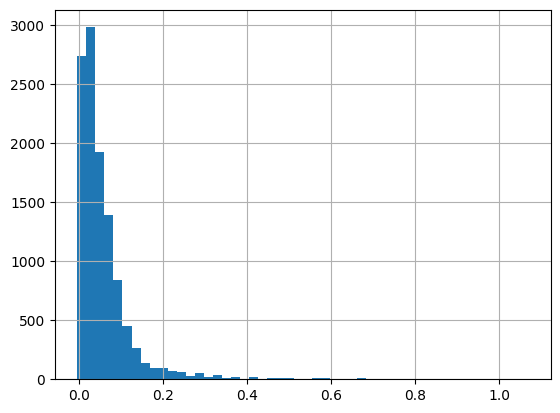

In [5]:
sdf = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['amp_mid', 'mlthres'])[(df['mlthres'] == 0.8) & (df['rv_fetch'] > 100) & (df['rv_fetch'] / df['misses'] > 0.01)]
sdf['amp_mid'].hist(bins=50)

In [26]:
cdf = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['amp_mid', 'mlthres'])
cdf = cdf[(cdf['rv_fetch'] > 100) & (cdf['rv_fetch'] / cdf['misses'] > 0.01) & (cdf['mlthres'] >= 0.55) & (cdf['misses'] > 600)]
cdf['overhead_pct'] = cdf['amp_mid'] * 100
order = sorted(cdf['mlthres'].unique())

In [27]:
cdf[cdf['overhead_pct'] > 100]

,zone,requests,hits,misses,rv_fetch,rv_good,rv_wasted,in,mlthres,rv_max_za,amp_lower,amp_upper,amp_mid,maxza,overhead_pct
81369,1771378280680051507,25753,25010,743,5670,4836,834,a,0.70,0.16,1.122476,1.122476,1.122476,16,112.247645
92887,1771378280680051507,25753,25047,706,5761,4884,877,a,0.68,0.16,1.242210,1.242210,1.242210,16,124.220963
103766,1771378280680051507,25753,25013,740,5728,4848,879,a,0.66,0.16,1.187838,1.189189,1.188514,16,118.851351
185133,15591189152524442964,1718929,1700216,18713,149186,128095,21092,c,0.68,0.16,1.127131,1.127077,1.127104,16,112.710415
186581,3127884313652954563,12179,5895,6284,57474,48,57426,c,0.66,0.02,9.138447,9.138447,9.138447,2,913.844685
188500,3127884313652954563,12179,5894,6285,57474,48,57426,c,0.66,0.04,9.136993,9.136993,9.136993,4,913.699284
190012,3127884313652954563,12179,5894,6285,57474,48,57426,c,0.66,0.06,9.136993,9.136993,9.136993,6,913.699284
190818,3127884313652954563,12179,5894,6285,57474,48,57426,c,0.66,0.08,9.136993,9.136993,9.136993,8,913.699284
193086,3127884313652954563,12179,5894,6285,57474,48,57426,c,0.66,0.10,9.136993,9.136993,9.136993,10,913.699284
193708,3127884313652954563,12179,5894,6285,57474,48,57426,c,0.66,0.13,9.136993,9.136993,9.136993,13,913.699284


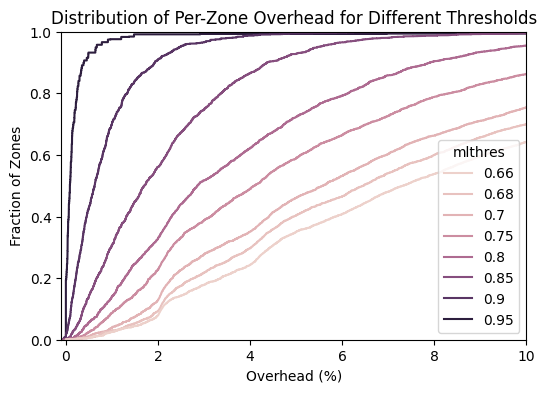

In [31]:
plt.figure(figsize=(6,4))
sns.ecdfplot(data=cdf, x='overhead_pct', hue='mlthres', hue_order=order)
plt.xlim(-0.1, 10)
plt.ylim(0, 1)
plt.xlabel('Overhead (%)')
plt.ylabel('Fraction of Zones')
plt.title('Distribution of Per-Zone Overhead for Different Thresholds')
# plt.savefig('../paper/figs/zone_overhead_cdf.png', bbox_inches='tight')
plt.show()

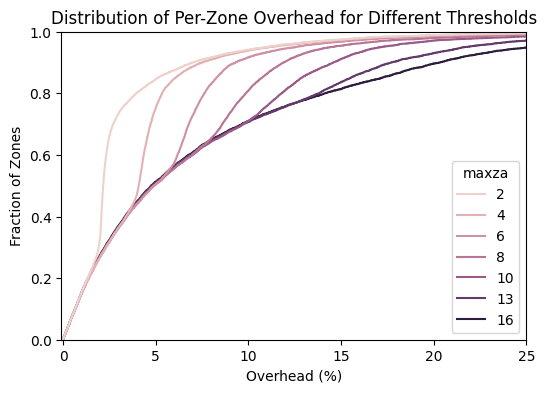

In [30]:
plt.figure(figsize=(6,4))
sns.ecdfplot(data=cdf, x='overhead_pct', hue='maxza', hue_order=order)
plt.xlim(-0.1, 25)
plt.ylim(0, 1)
plt.xlabel('Overhead (%)')
plt.ylabel('Fraction of Zones')
plt.title('Distribution of Per-Zone Overhead for Different Thresholds')
# plt.savefig('../paper/figs/zone_overhead_cdf.png', bbox_inches='tight')
plt.show()

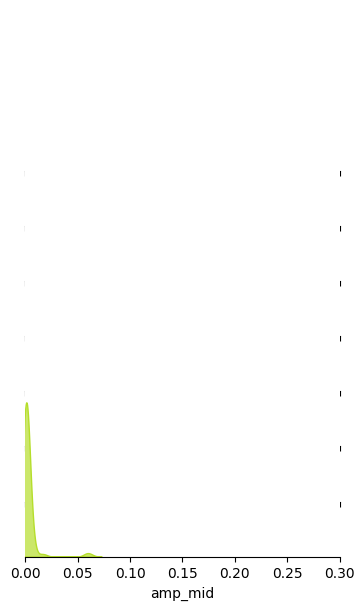

,zone,requests,hits,misses,rv_fetch,rv_good,rv_wasted,i,label,threshold,amp_lower,amp_upper,amp_mid,amp_binned
31,8918156210637760031,15720,13698,2022,153,150,3,7,a,0.95,0.001484,0.001484,0.001484,0.0025
45,12033714650239210777,20554,20537,17,134,133,1,7,a,0.95,0.058824,0.058824,0.058824,0.0575
48,2453608583509221352,43952,36591,7361,330,321,9,7,a,0.95,0.001223,0.001223,0.001223,0.0025
75,3148641899730471286,30548,30544,4,118,118,0,7,a,0.95,0.000000,0.000000,0.000000,NaN
97,12693851073660838258,42384,28012,14372,162,156,6,7,a,0.95,0.000417,0.000417,0.000417,0.0025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24833,12719211463693463023,173730,165770,7960,4016,3279,767,3,a,0.75,0.096357,0.092588,0.094472,0.0925
24834,160394671470823099,5064,4447,617,520,485,35,3,a,0.75,0.056726,0.056726,0.056726,0.0575
24837,15692541335355566438,3386,3162,224,234,201,36,3,a,0.75,0.160714,0.147321,0.154018,0.1525
24839,8200196179976821466,3067,2620,447,136,103,32,3,a,0.75,0.071588,0.073826,0.072707,0.0725


/tmp/ipykernel_938240/2021478135.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pivot_table = cdf.groupby(['threshold', 'amp_binned']).size().unstack(fill_value=0)


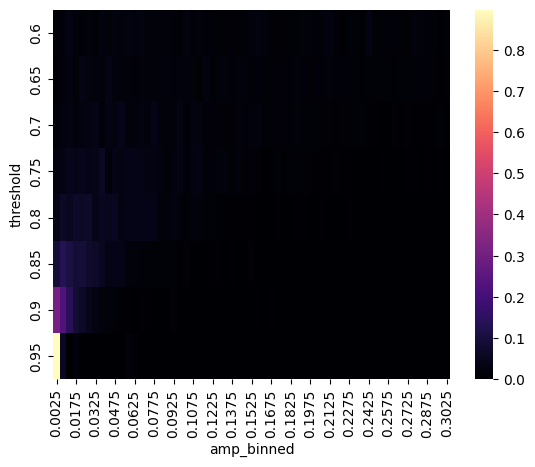

In [6]:
cdf = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['amp_mid', 'threshold'])
cdf = cdf[(cdf['rv_fetch'] > 100) & (cdf['rv_fetch'] / cdf['misses'] > 0.01) & (cdf['threshold'] >= 0.55)]
order = sorted(cdf['threshold'].unique())

# sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})
g = sns.FacetGrid(cdf, row='threshold', row_order=order, hue='threshold', aspect=5, height=.8, palette='viridis', sharey=True)
g.map(sns.kdeplot, 'amp_mid', fill=True, alpha=0.7, bw_adjust=1)
g.figure.subplots_adjust(hspace=-.66) # Overlap effect
# g.map(plt.axhline, y=0, lw=0.5, color='gray', clip_on=False)
# g.set_titles(row_template='threshold={row_name}')
g.set_titles('')
# g.set(yscale='log')
g.set(yticks=[], ylabel='')
g.set(xlim=(0, 0.3))
g.despine(left=True)
plt.show()

cdf['amp_binned'] = pd.cut(cdf['amp_mid'], bins=np.arange(0, 0.31, 0.005)).apply(lambda x: x.mid)
display(cdf)
pivot_table = cdf.groupby(['threshold', 'amp_binned']).size().unstack(fill_value=0)
pivot_norm = pivot_table.div(pivot_table.sum(axis=1), axis=0)
h = sns.heatmap(pivot_norm, cmap='magma')

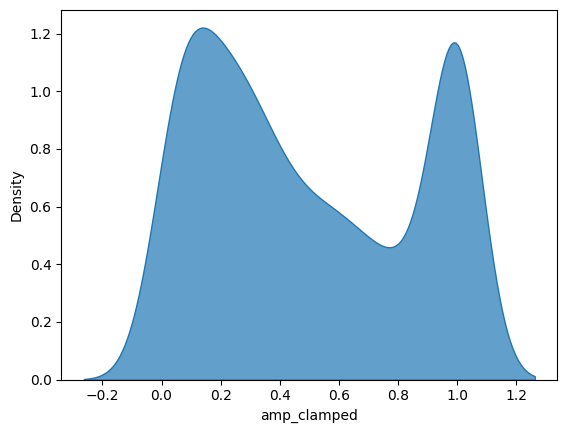

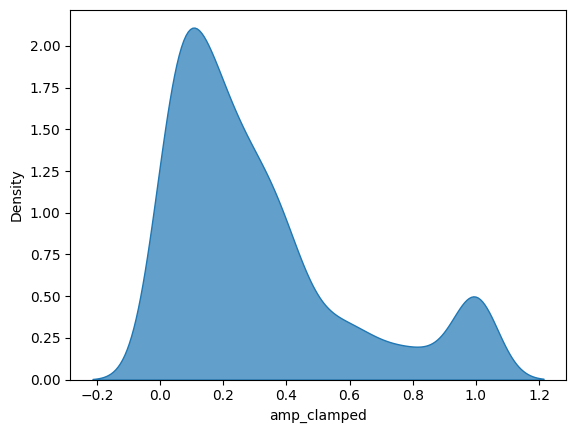

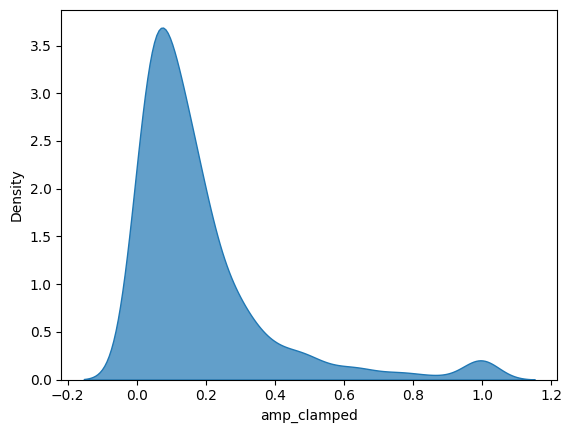

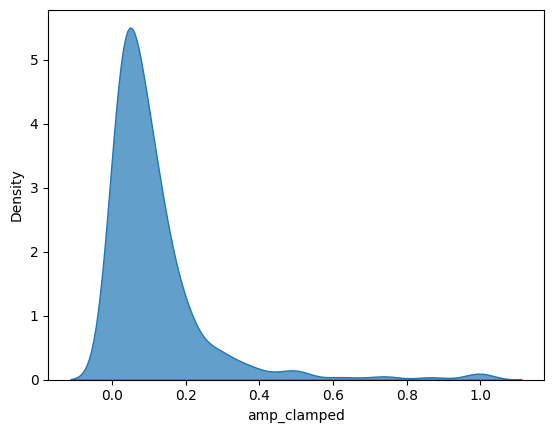

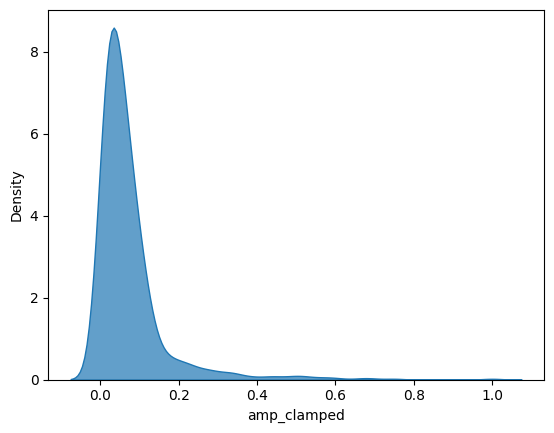

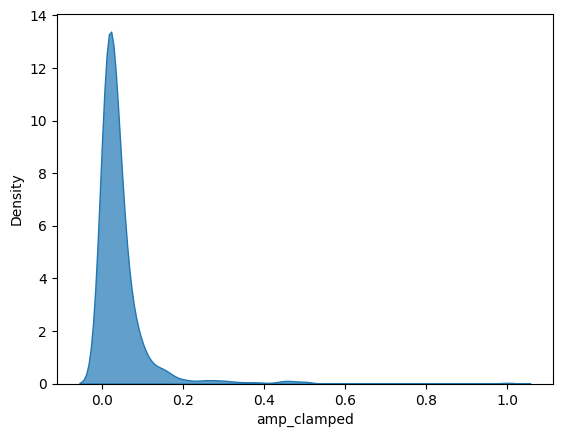

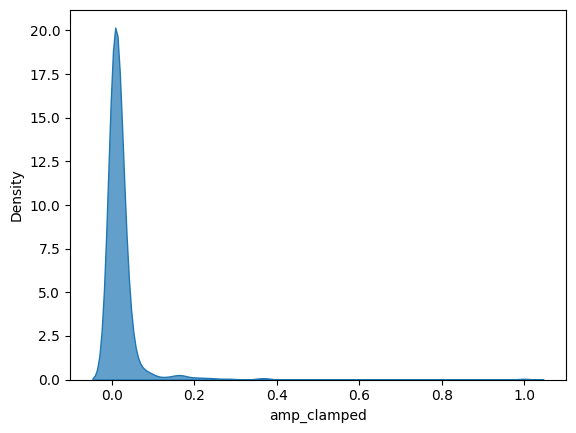

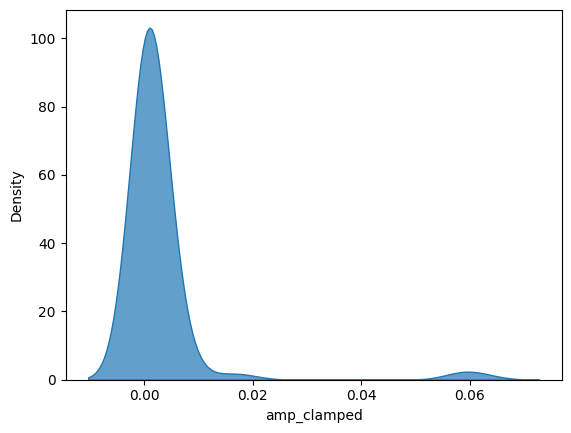

In [7]:
cdf['amp_clamped'] = cdf['amp_mid'].clip(0, 1)
for t in order:
    sns.kdeplot(cdf[cdf['threshold'] == t]['amp_clamped'], fill=True, alpha=0.7, bw_adjust=1, label=f'threshold={t}', common_norm=False)
    plt.show()

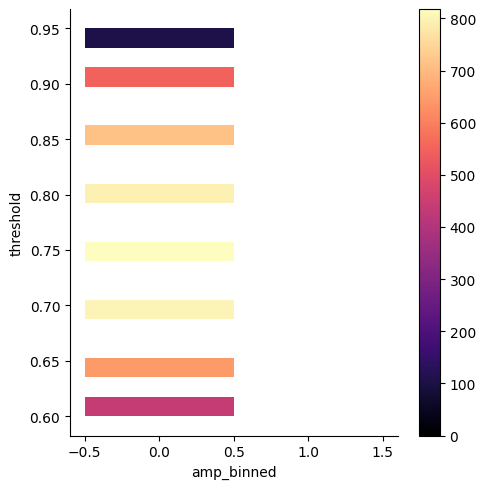

In [8]:
sns.displot(
    data=cdf, x="amp_binned", y="threshold", 
    # log_scale=(False, True), 
    cbar=True, cmap="magma"
)